# 3D Heterogeneous Seepage SSR (COMSOL Mesh)

This notebook is a structured Jupyter version of `slope_stability_3D_hetero_seepage_SSR_comsol.m`.

It performs:
1. Mesh and quadrature setup
2. Seepage solution
3. Mechanical assembly
4. SSR continuation solve
5. Inline visualization in notebook output

## Notes Before Running

- This workflow is computationally expensive (large 3D model).
- It uses project package folders (`+ASSEMBLY`, `+MESH`, `+SEEPAGE`, `+VIZ`, etc.).
- The default linear solver is `DFGMRES_HYPRE_BOOMERAMG`.
- Inline plotting is enabled for Octave kernel using `%plot -f png`.

In [1]:
%plot -f png -r 600
% Load sparsersb for multithreaded sparse matrix-vector products
pkg load sparsersb;

% Configure toolkit for both GUI and headless Jupyter environments.
graphics_toolkit('qt');
set(0, 'defaultfigurevisible', 'off');

fprintf('Working directory: %s\n', pwd);
fprintf('Graphics toolkit: %s\n', graphics_toolkit());


Working directory: /home/beremi/repos/slope_stability/slope_stability
Graphics toolkit: qt


## 1) Main Input Data

Define FE type, material properties, geometry, and mesh density.

In [2]:

% elem_type - type of finite elements; available choices: 'P1', 'P2'
elem_type='P2';

% Davis_type - choice of Davis' approach; available choices: 'A','B','C'
Davis_type='B';

% Mechanical parameters per subdomain:
% [c0, phi, psi, young, poisson, gamma_sat, gamma_unsat]
mat_props = [15, 30,  0, 10000, 0.33, 19, 19;  % Cover layer
    15, 38,  0, 50000, 0.30, 22, 22;  % General foundation
    10, 35,  0, 50000, 0.30, 21, 21;  % Relatively weak foundation
    18, 32,  0, 20000, 0.33, 20, 20;  % General slope mass
    ];

% Hydraulic conductivity for each subdomain [m/s]
k = 1.0;

% Geometrical parameters
x1 = 15;  % length in front of slope
x2 = 10;  % slope length in x
x3 = 15;  % length behind slope
y1 = 10;  % height below slope
y2 = 10;  % slope height
z  = 5;   % length in z direction

% Mesh density parameter
N_h = 1;


## 2) Reference Element Data and Mesh Load

Build quadrature/basis data and load COMSOL mesh.

In [3]:
% quadrature points and weights for volume integration
[Xi, WF] = ASSEMBLY.quadrature_volume_3D(elem_type);

% local basis functions and their derivatives
[HatP, DHatP1, DHatP2, DHatP3] = ASSEMBLY.local_basis_volume_3D(elem_type, Xi);

% Mesh file
file_path = 'meshes/comsol_mesh.h5';
[coord, elem, surf, Q, material, triangle_labels] = MESH.load_mesh_P2(file_path, 1);

% Uncomment to reduce matrix bandwidth via Reverse Cuthill-McKee node reordering:
[coord, elem, surf, Q] = MESH.reorder_mesh(coord, elem, surf, Q);

% Mesh statistics
n_n = size(coord,2);
n_unknown = length(coord(Q));
n_e = size(elem,2);
n_q = length(WF);
n_int = n_e * n_q;

fprintf('\n');
fprintf('Mesh data:');
fprintf('  number of nodes =%d ', n_n);
fprintf('  number of unknowns =%d ', n_unknown);
fprintf('  number of elements =%d ', n_e);
fprintf('  number of integration points =%d ', n_int);
fprintf('\n');

% Homogeneous identifier for seepage helper call
material_identifier = zeros(1, n_e);

  Mesh reordering (symrcm): bandwidth 69441 -> 80266 (0.9x reduction)

Mesh data:  number of nodes =80226   number of unknowns =231201   number of elements =55895   number of integration points =614845 


### Mesh Preview

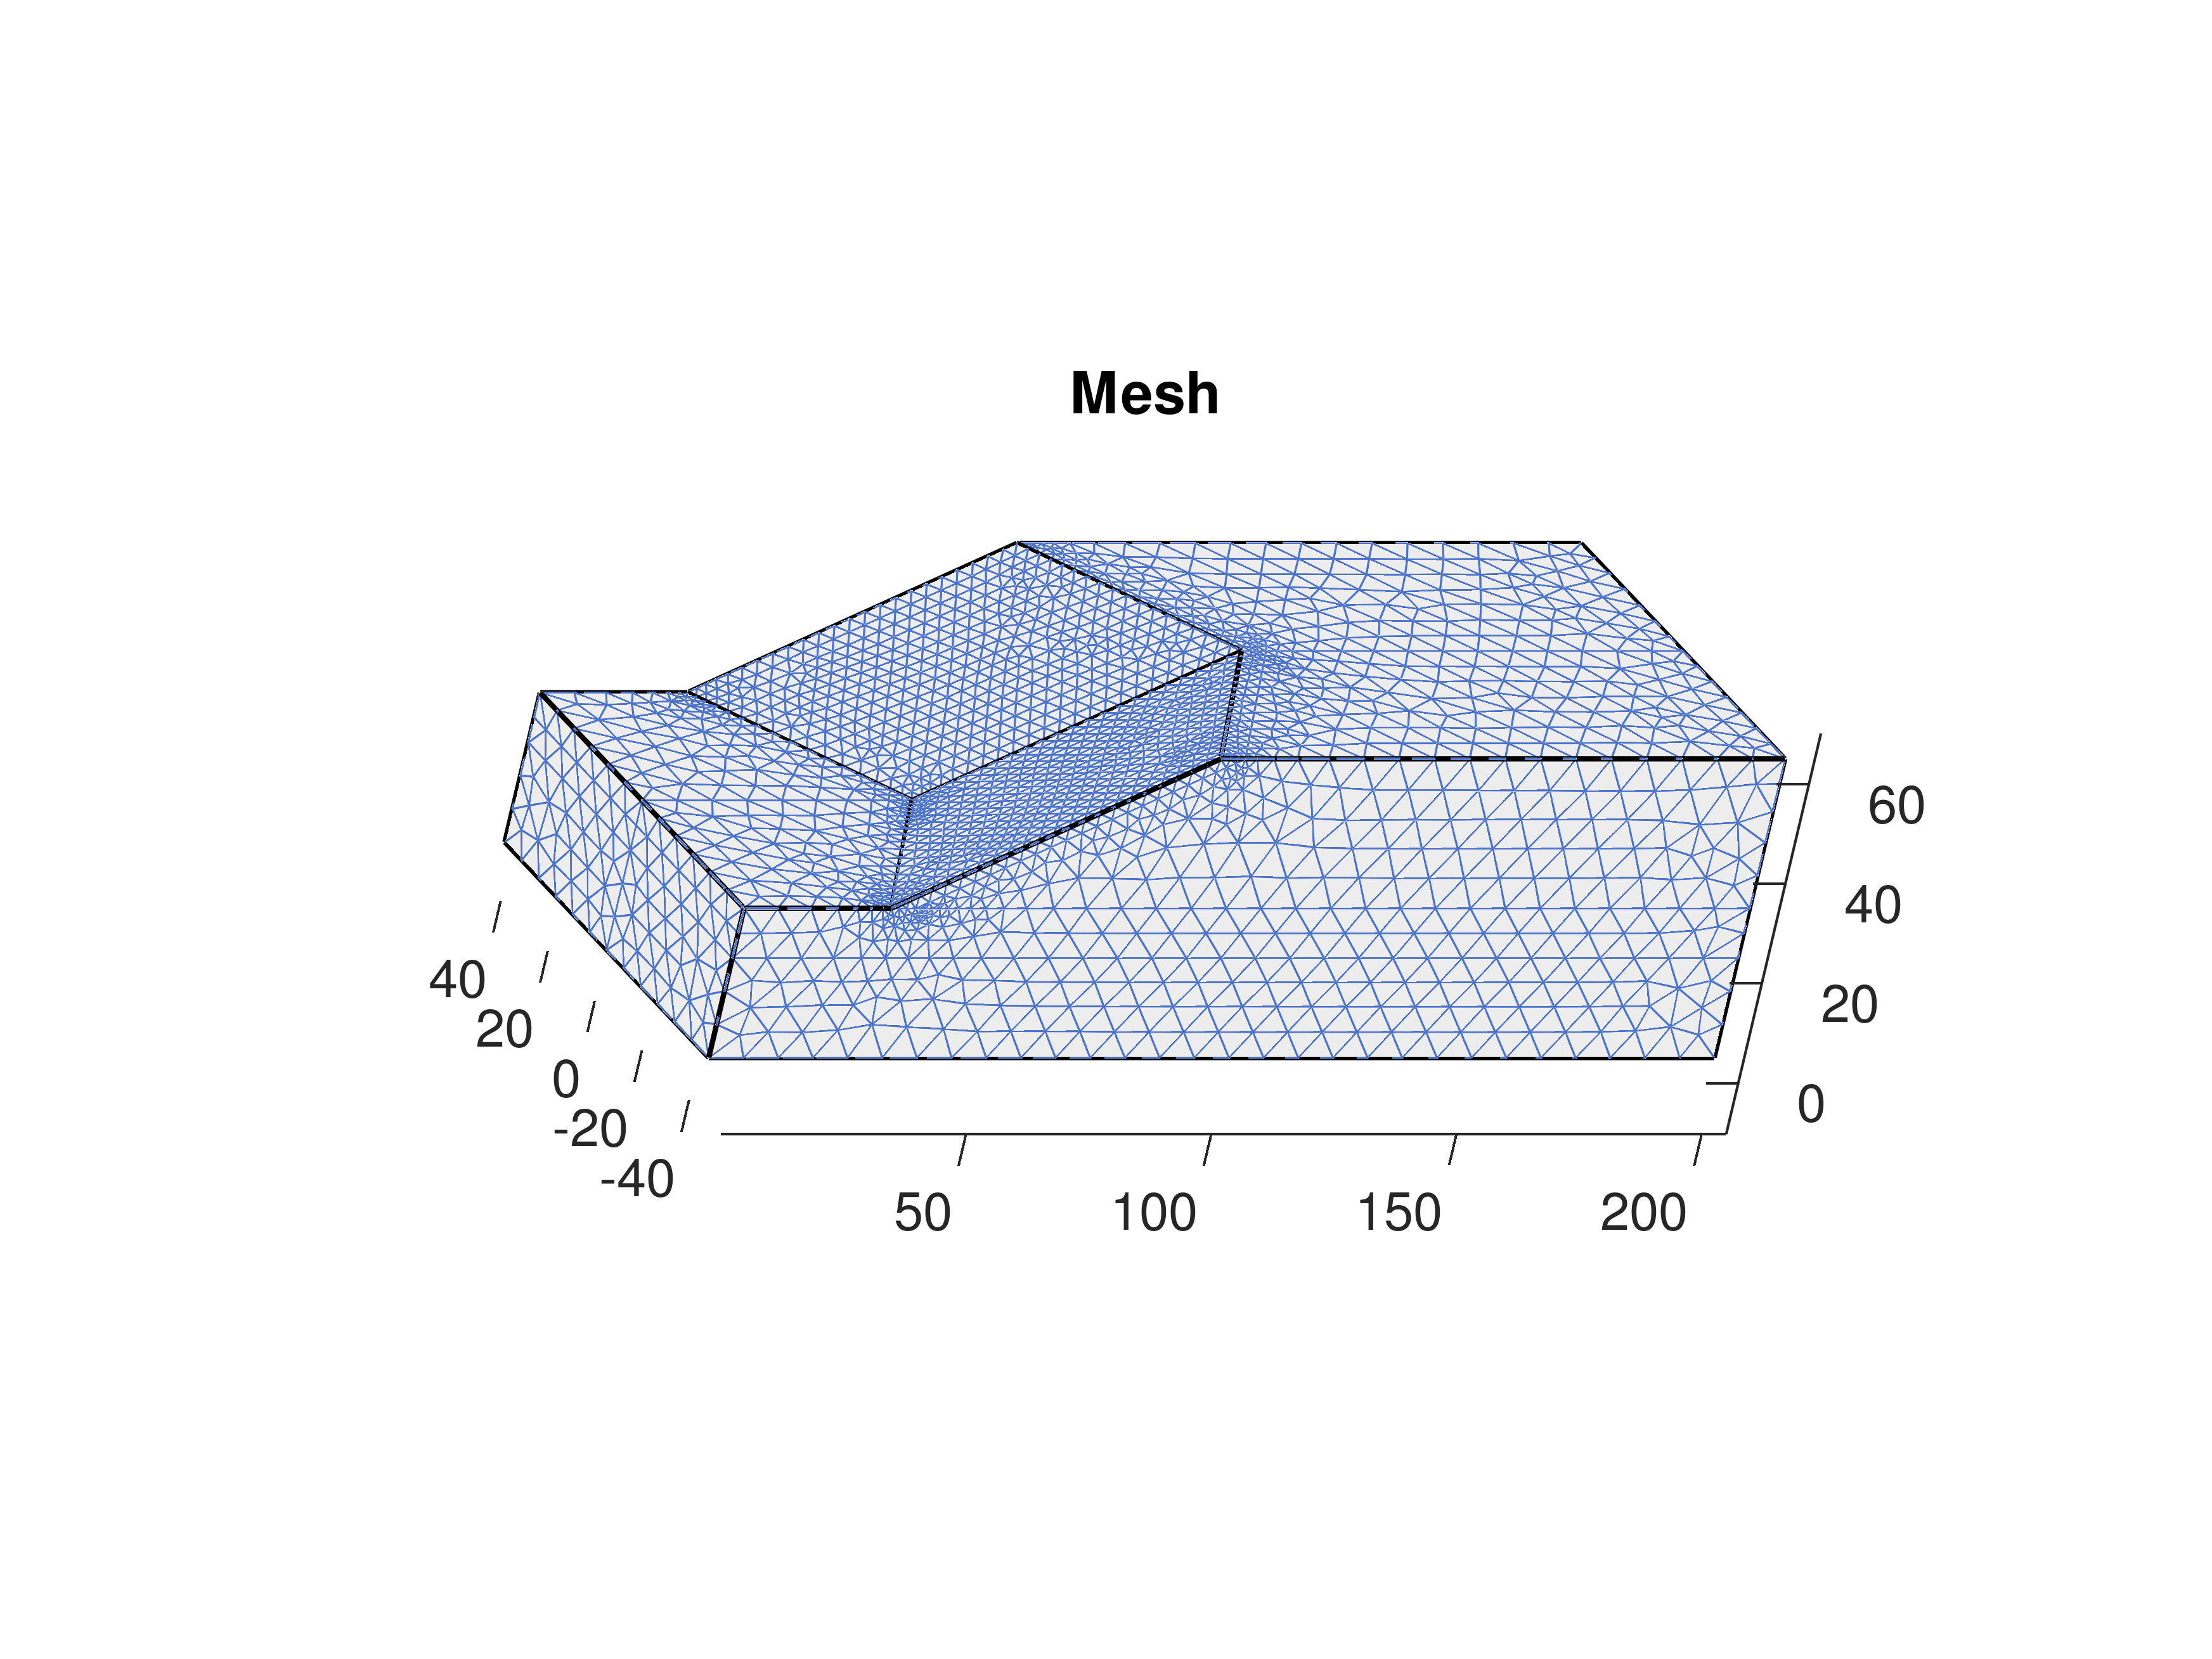

In [4]:
% Create the plotter early so we can visualise intermediate results.
plotter = VIZ.SolutionPlotter(coord, elem, surf);
plotter.plot_mesh();
drawnow;

## 3) Seepage Problem

Solve pore pressure and saturation state.

In [5]:
% Hydraulic conductivity at each integration point
conduct0 = SEEPAGE.heter_conduct(material_identifier, n_q, k);

% Specific weight of water [kPa]
grho = 9.81;

% Boundary conditions from COMSOL-labeled surfaces
[Q_w, pw_D] = MESH.seepage_boundary_3D_hetero_comsol(coord, surf, triangle_labels, grho);

% Set up iterative solver for the seepage problem (scalar BoomerAMG, no nullspace)
seepage_boomeramg_opts = struct('threads', 16, 'print_level', 0, ...
    'use_as_preconditioner', true);
seepage_solver = LINEAR_SOLVERS.set_linear_solver('agmg', 'DFGMRES_HYPRE_BOOMERAMG', ...
    1e-3, 200, 1e-3, 1, Q_w, [], seepage_boomeramg_opts);

% Solve seepage (DFGMRES + HYPRE inside Newton iterations)
[pw, grad_p, mater_sat] = SEEPAGE.seepage_problem_3D( ...
    coord, elem, Q_w, pw_D, grho, conduct0, HatP, DHatP1, DHatP2, DHatP3, WF, seepage_solver);

% Clean up HYPRE instance used for seepage
LINEAR_SOLVERS.hypre_boomeramg_clear();

% Integration-point saturation mask
mater_sat_ext = repmat(mater_sat, n_q, 1);
saturation = mater_sat_ext(:);

4|4|  seepage newton it=1  resid=6.70e-02  alpha=0.50
5|  seepage newton it=2  resid=8.16e-02  alpha=0.25
5|  seepage newton it=3  resid=8.64e-02  alpha=0.25
11|  seepage newton it=4  resid=8.93e-02  alpha=0.25
10|  seepage newton it=5  resid=8.64e-02  alpha=0.25
14|  seepage newton it=6  resid=7.93e-02  alpha=0.25
16|  seepage newton it=7  resid=7.04e-02  alpha=0.25
17|  seepage newton it=8  resid=6.05e-02  alpha=0.25
22|  seepage newton it=9  resid=5.06e-02  alpha=0.25
19|  seepage newton it=10  resid=4.15e-02  alpha=0.25
18|  seepage newton it=11  resid=3.32e-02  alpha=0.25
23|  seepage newton it=12  resid=2.59e-02  alpha=0.50
22|  seepage newton it=13  resid=1.35e-02  alpha=1.00
19|  seepage newton it=14  resid=6.79e-04  alpha=1.00
24|  seepage newton it=15  resid=1.00e-05  alpha=1.00
28|  seepage newton it=16  resid=1.77e-07  alpha=1.00
28|  seepage newton it=17  resid=2.53e-10  alpha=1.00
27|  seepage newton it=18  resid=7.23e-14  alpha=1.00
Seepage Newton converges: iteration = 

In [14]:
% Hydraulic conductivity at each integration point
conduct0 = SEEPAGE.heter_conduct(material_identifier, n_q, k);

% Specific weight of water [kPa]
grho = 9.81;

% Boundary conditions from COMSOL-labeled surfaces
[Q_w, pw_D] = MESH.seepage_boundary_3D_hetero_comsol(coord, surf, triangle_labels, grho);

% Set up iterative solver for the seepage problem (scalar BoomerAMG, no nullspace)
seepage_boomeramg_opts = struct('threads', 16, 'print_level', 0, ...
    'use_as_preconditioner', true);
seepage_solver = LINEAR_SOLVERS.set_linear_solver('agmg', 'DFGMRES_HYPRE_BOOMERAMG', ...
    1e-3, 200, 1e-3, 1, Q_w, [], seepage_boomeramg_opts);

% Enable profiler
profile on;

% Run the seepage problem 
[pw, grad_p, mater_sat] = SEEPAGE.seepage_problem_3D( ...
    coord, elem, Q_w, pw_D, grho, conduct0, HatP, DHatP1, DHatP2, DHatP3, WF, seepage_solver);

% Disable profiler and display results
profile off;
profdata = profile('info');
profshow(profdata, 10);  % Show top 10 functions by time

% Clean up HYPRE instance used for seepage
LINEAR_SOLVERS.hypre_boomeramg_clear();

% Integration-point saturation mask
mater_sat_ext = repmat(mater_sat, n_q, 1);
saturation = mater_sat_ext(:);

4|4|  seepage newton it=1  resid=6.70e-02  alpha=0.50
5|  seepage newton it=2  resid=8.16e-02  alpha=0.25
5|  seepage newton it=3  resid=8.64e-02  alpha=0.25
11|  seepage newton it=4  resid=8.93e-02  alpha=0.25
10|  seepage newton it=5  resid=8.64e-02  alpha=0.25
14|  seepage newton it=6  resid=7.93e-02  alpha=0.25
16|  seepage newton it=7  resid=7.04e-02  alpha=0.25
17|  seepage newton it=8  resid=6.05e-02  alpha=0.25
22|  seepage newton it=9  resid=5.06e-02  alpha=0.25
19|  seepage newton it=10  resid=4.15e-02  alpha=0.25
18|  seepage newton it=11  resid=3.32e-02  alpha=0.25
23|  seepage newton it=12  resid=2.59e-02  alpha=0.50
22|  seepage newton it=13  resid=1.35e-02  alpha=1.00
19|  seepage newton it=14  resid=6.79e-04  alpha=1.00
24|  seepage newton it=15  resid=1.00e-05  alpha=1.00
28|  seepage newton it=16  resid=1.77e-07  alpha=1.00
28|  seepage newton it=17  resid=2.53e-10  alpha=1.00
27|  seepage newton it=18  resid=7.23e-14  alpha=1.00
Seepage Newton converges: iteration = 

### Pore Pressure Preview

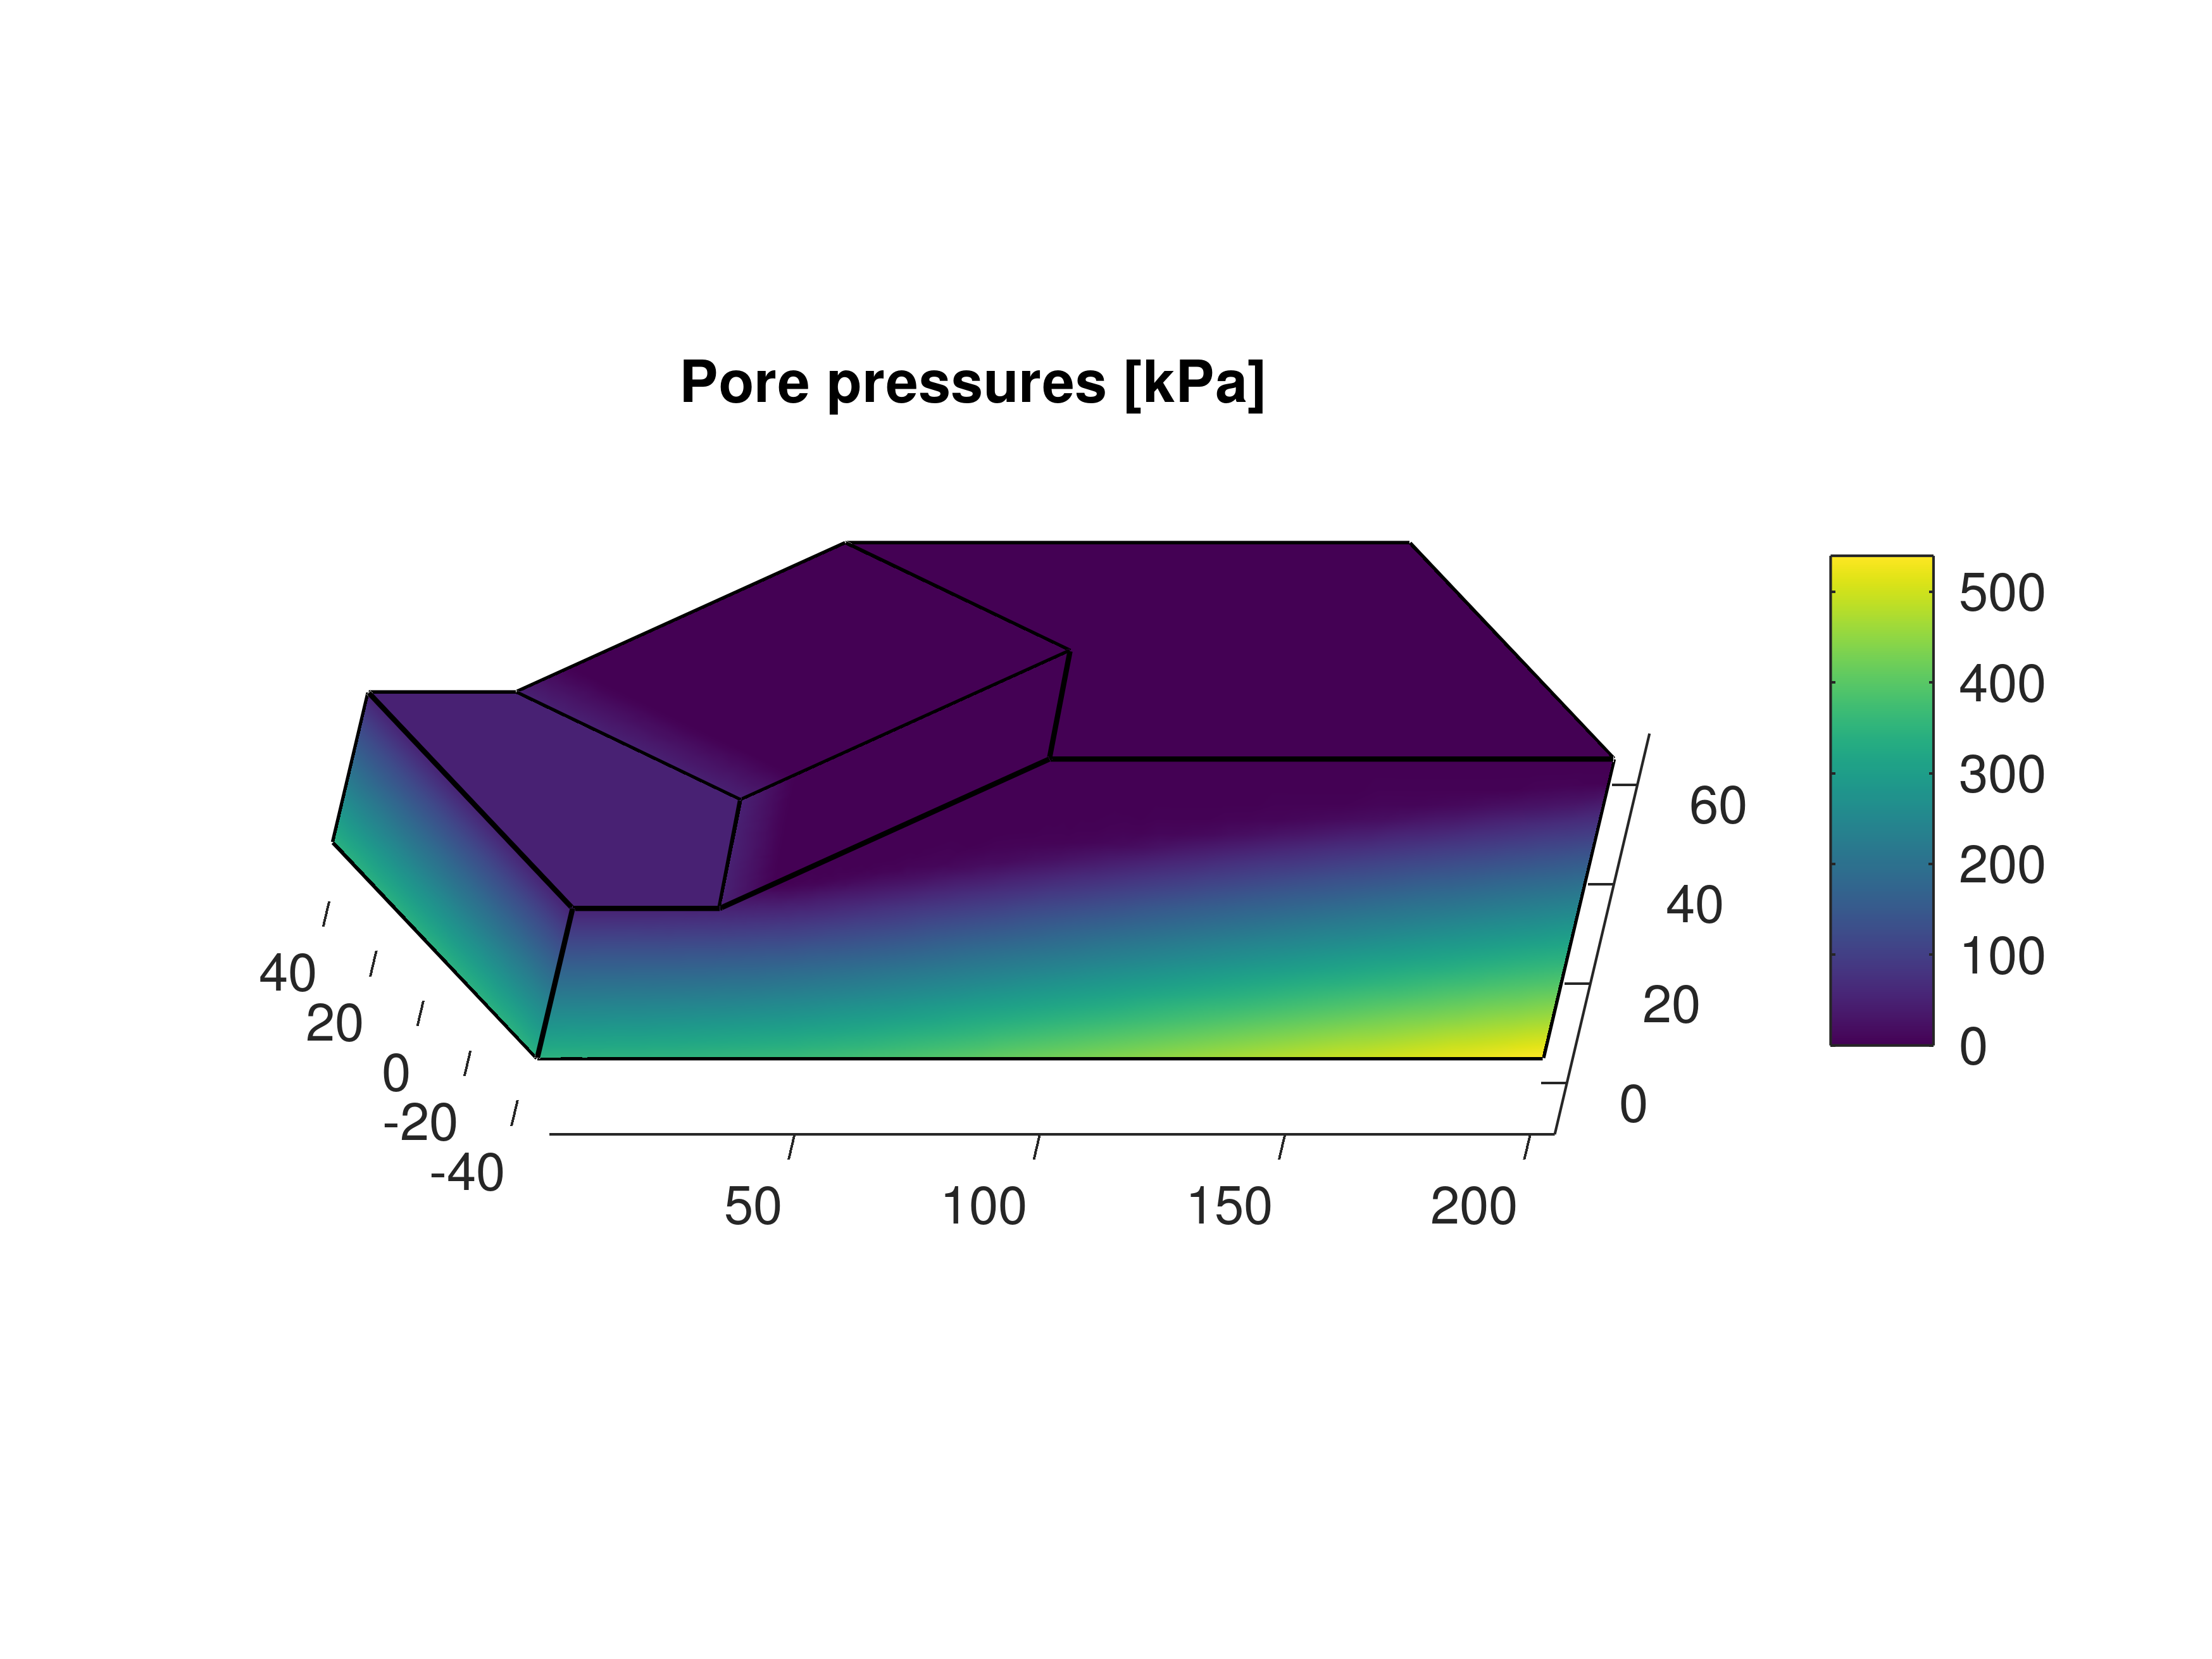

In [6]:
plotter.set_pore_pressure(pw);
plotter.plot_pore_pressure();
drawnow;

## 4) Mechanical Material Fields and Assembly

Map material properties to integration points and assemble elastic stiffness and body-force vector.

In [7]:
fields = {'c0', 'phi', 'psi', 'young', 'poisson', 'gamma_sat', 'gamma_unsat'};
materials = cellfun(@(x) cell2struct(num2cell(x), fields, 2), num2cell(mat_props, 2), 'UniformOutput', false);

[c0, phi, psi, shear, bulk, lame, gamma] = ...
    ASSEMBLY.heterogenous_materials(material, saturation, n_q, materials);

% Elastic stiffness matrix + element-level derivative data (DPhi1/2/3)
[K_elast, B, WEIGHT, DPhi1_out, DPhi2_out, DPhi3_out] = ASSEMBLY.elastic_stiffness_matrix_3D(
    elem, coord, shear, bulk, DHatP1, DHatP2, DHatP3, WF);

% Volume forces at integration points: mechanical-only baseline
f_V_int = [zeros(1, n_int); -gamma; zeros(1, n_int)];
f_V = ASSEMBLY.vector_volume_3D(elem, coord, f_V_int, HatP, WEIGHT);

In [8]:
% Attach strain data to the plotter for later slice visualisation.
plotter.set_strain_data(B, Xi);

## 5) Continuation, Newton, and Linear Solver Parameters

In [9]:
% Continuation parameters
lambda_init = 1.0;
d_lambda_init = 0.1;
d_lambda_min = 1e-5;
d_lambda_diff_scaled_min = 0.01;
omega_max_stop = 340700000;
step_max = 100;

% Newton parameters
it_newt_max = 50;
it_damp_max = 10;
tol = 1e-4;
r_min = 1e-4;

% Linear solver settings
agmg_folder = "agmg";
solver_type = 'DFGMRES_HYPRE_BOOMERAMG';

linear_solver_tolerance = 1e-1;
linear_solver_maxit = 100;
deflation_basis_tolerance = 1e-3;
linear_solver_printing = 1;

boomeramg_opts = struct('threads', 16, 'print_level', 0, ...
    'use_as_preconditioner', true);

linear_system_solver = LINEAR_SOLVERS.set_linear_solver(agmg_folder, solver_type, ...
    linear_solver_tolerance, linear_solver_maxit, deflation_basis_tolerance, ...
    linear_solver_printing, Q, coord, boomeramg_opts);

% Constitutive model object
n_strain = 6;
constitutive_matrix_builder = CONSTITUTIVE_PROBLEM.CONSTITUTIVE(
    B, c0, phi, psi, Davis_type, shear, bulk, lame, WEIGHT, n_strain, n_int, 3);

% Provide element geometry for fast element-level tangent assembly (208x speedup).
% This enables the C mex kernel instead of global B'*D*B sparse triple product.
constitutive_matrix_builder.set_element_data(elem, DPhi1_out, DPhi2_out, DPhi3_out);

% Attach shared profiler to both objects (class-level instrumentation)
profiler = PROFILING.Profiler();
constitutive_matrix_builder.profiler = profiler;
linear_system_solver.profiler = profiler;

Element data set: n_p=10, n_e=55895, n_q=11, mex=1


## 6) Run SSR Continuation

By default in this demonstration notebook:
- `direct_on = 0`
- `indirect_on = 1`

In [10]:
direct_on = 0;
indirect_on = 1;

if direct_on
    fprintf('\n Direct continuation method\n');
    tic;
    [U2, lambda_hist2, omega_hist2, Umax_hist2] = CONTINUATION.SSR_direct_continuation(...
        lambda_init, d_lambda_init, d_lambda_min, d_lambda_diff_scaled_min, step_max, ...
        it_newt_max, it_damp_max, tol, r_min, K_elast, Q, f_V, ...
        constitutive_matrix_builder, linear_system_solver.copy());
    time_run = toc;
    fprintf('Running_time = %f \n', time_run);
end

if indirect_on
    fprintf('\n Indirect continuation method\n');
    tic;
    [U3, lambda_hist3, omega_hist3, Umax_hist3, stats] = CONTINUATION.SSR_indirect_continuation(...
        lambda_init, d_lambda_init, d_lambda_min, d_lambda_diff_scaled_min, step_max, ...
        omega_max_stop, it_newt_max, it_damp_max, tol, r_min, K_elast, Q, f_V, ...
        constitutive_matrix_builder, linear_system_solver.copy());
    time_run = toc;
    fprintf('Running_time = %f \n', time_run);
end

if ~isempty(strfind(upper(char(solver_type)), 'BOOMERAMG'))
    LINEAR_SOLVERS.hypre_boomeramg_clear();
end


 Indirect continuation method
Initialising K_r(Q,Q) sparse pattern ... done  (30.0 s, n_Q = 231201, nnz = 18763319)
Building element scatter map ... done  (4.4 s, n_local_dof=30, map_size=402 MB)

 Step = 1  
3|  newton it=1  resid=1.00e+00  alpha=1.00  r=0.0001
2|  newton it=2  resid=5.26e-02  alpha=1.00  r=0.0001
3|  newton it=3  resid=5.08e-03  alpha=1.00  r=0.0001
3|  newton it=4  resid=4.44e-04  alpha=1.00  r=0.0001
Newton method converges: iteration = 5, stopping criterion = 6.362793e-05
   lambda_init = 1, d_lambda_init = 0.1, omega_init = 6013302.5825

 Step = 2  
3|  newton it=1  resid=5.09e-03  alpha=0.97  r=0.0001
2|  newton it=2  resid=2.56e-03  alpha=1.00  r=0.0001
3|  newton it=3  resid=1.55e-04  alpha=1.00  r=0.0001
Newton method converges: iteration = 4, stopping criterion = 8.265284e-06
   lambda1 = 1, lambda2 = 1.1, d_lambda = 0.1, omega1 = 6013302.5825, omega2 = 6013371.839, d_omega = 69.2565

 Step = 3

3|3|  newton_ind_SSR it=1  resid=5.63e-03  alpha=1.00  r=0.000

## Profiler Summary

Display accumulated timing from all CONSTITUTIVE and DFGMRES methods, collected automatically by the shared `Profiler` handle.

In [11]:
profiler.print_summary();


  Profiler Summary
  Time      %       Calls  Operation
  --------- ------ ------  ------------------------------
    115.58s  34.3%    331  DFGMRES.solve
     56.48s  16.8%    135  DFGMRES.update_preconditioner
     36.10s  10.7%    422  CONSTITUTIVE.stress
     29.78s   8.8%    597  CONSTITUTIVE.reduction
     29.11s   8.6%    169  DFGMRES.A_orthogonalize
     23.54s   7.0%    620  CONSTITUTIVE.build_F
     20.70s   6.1%    198  CONSTITUTIVE.stress_tangent
     14.16s   4.2%     34  DFGMRES.setup_preconditioner
      9.94s   2.9%    169  CONSTITUTIVE.build_K_tangent_QQ_vals
      1.71s   0.5%    354  DFGMRES.expand_deflation_basis
  --------- ------ ------  ------------------------------
    337.10s                TOTAL

  Sub-profile: DFGMRES.solve  (115.58s total, 331 calls)
  --------- ------ ------  ------------------------------
     73.08s  63.2%    260  precond_apply
     20.44s  17.7%    260  deflation_project
     14.50s  12.5%    331  init
      3.74s   3.2%    260  matvec

## 7) Mechanical Results and Convergence

Register SSR solutions and plot displacements, deviatoric strain (with slices), and convergence curves.

Notebook workflow completed.


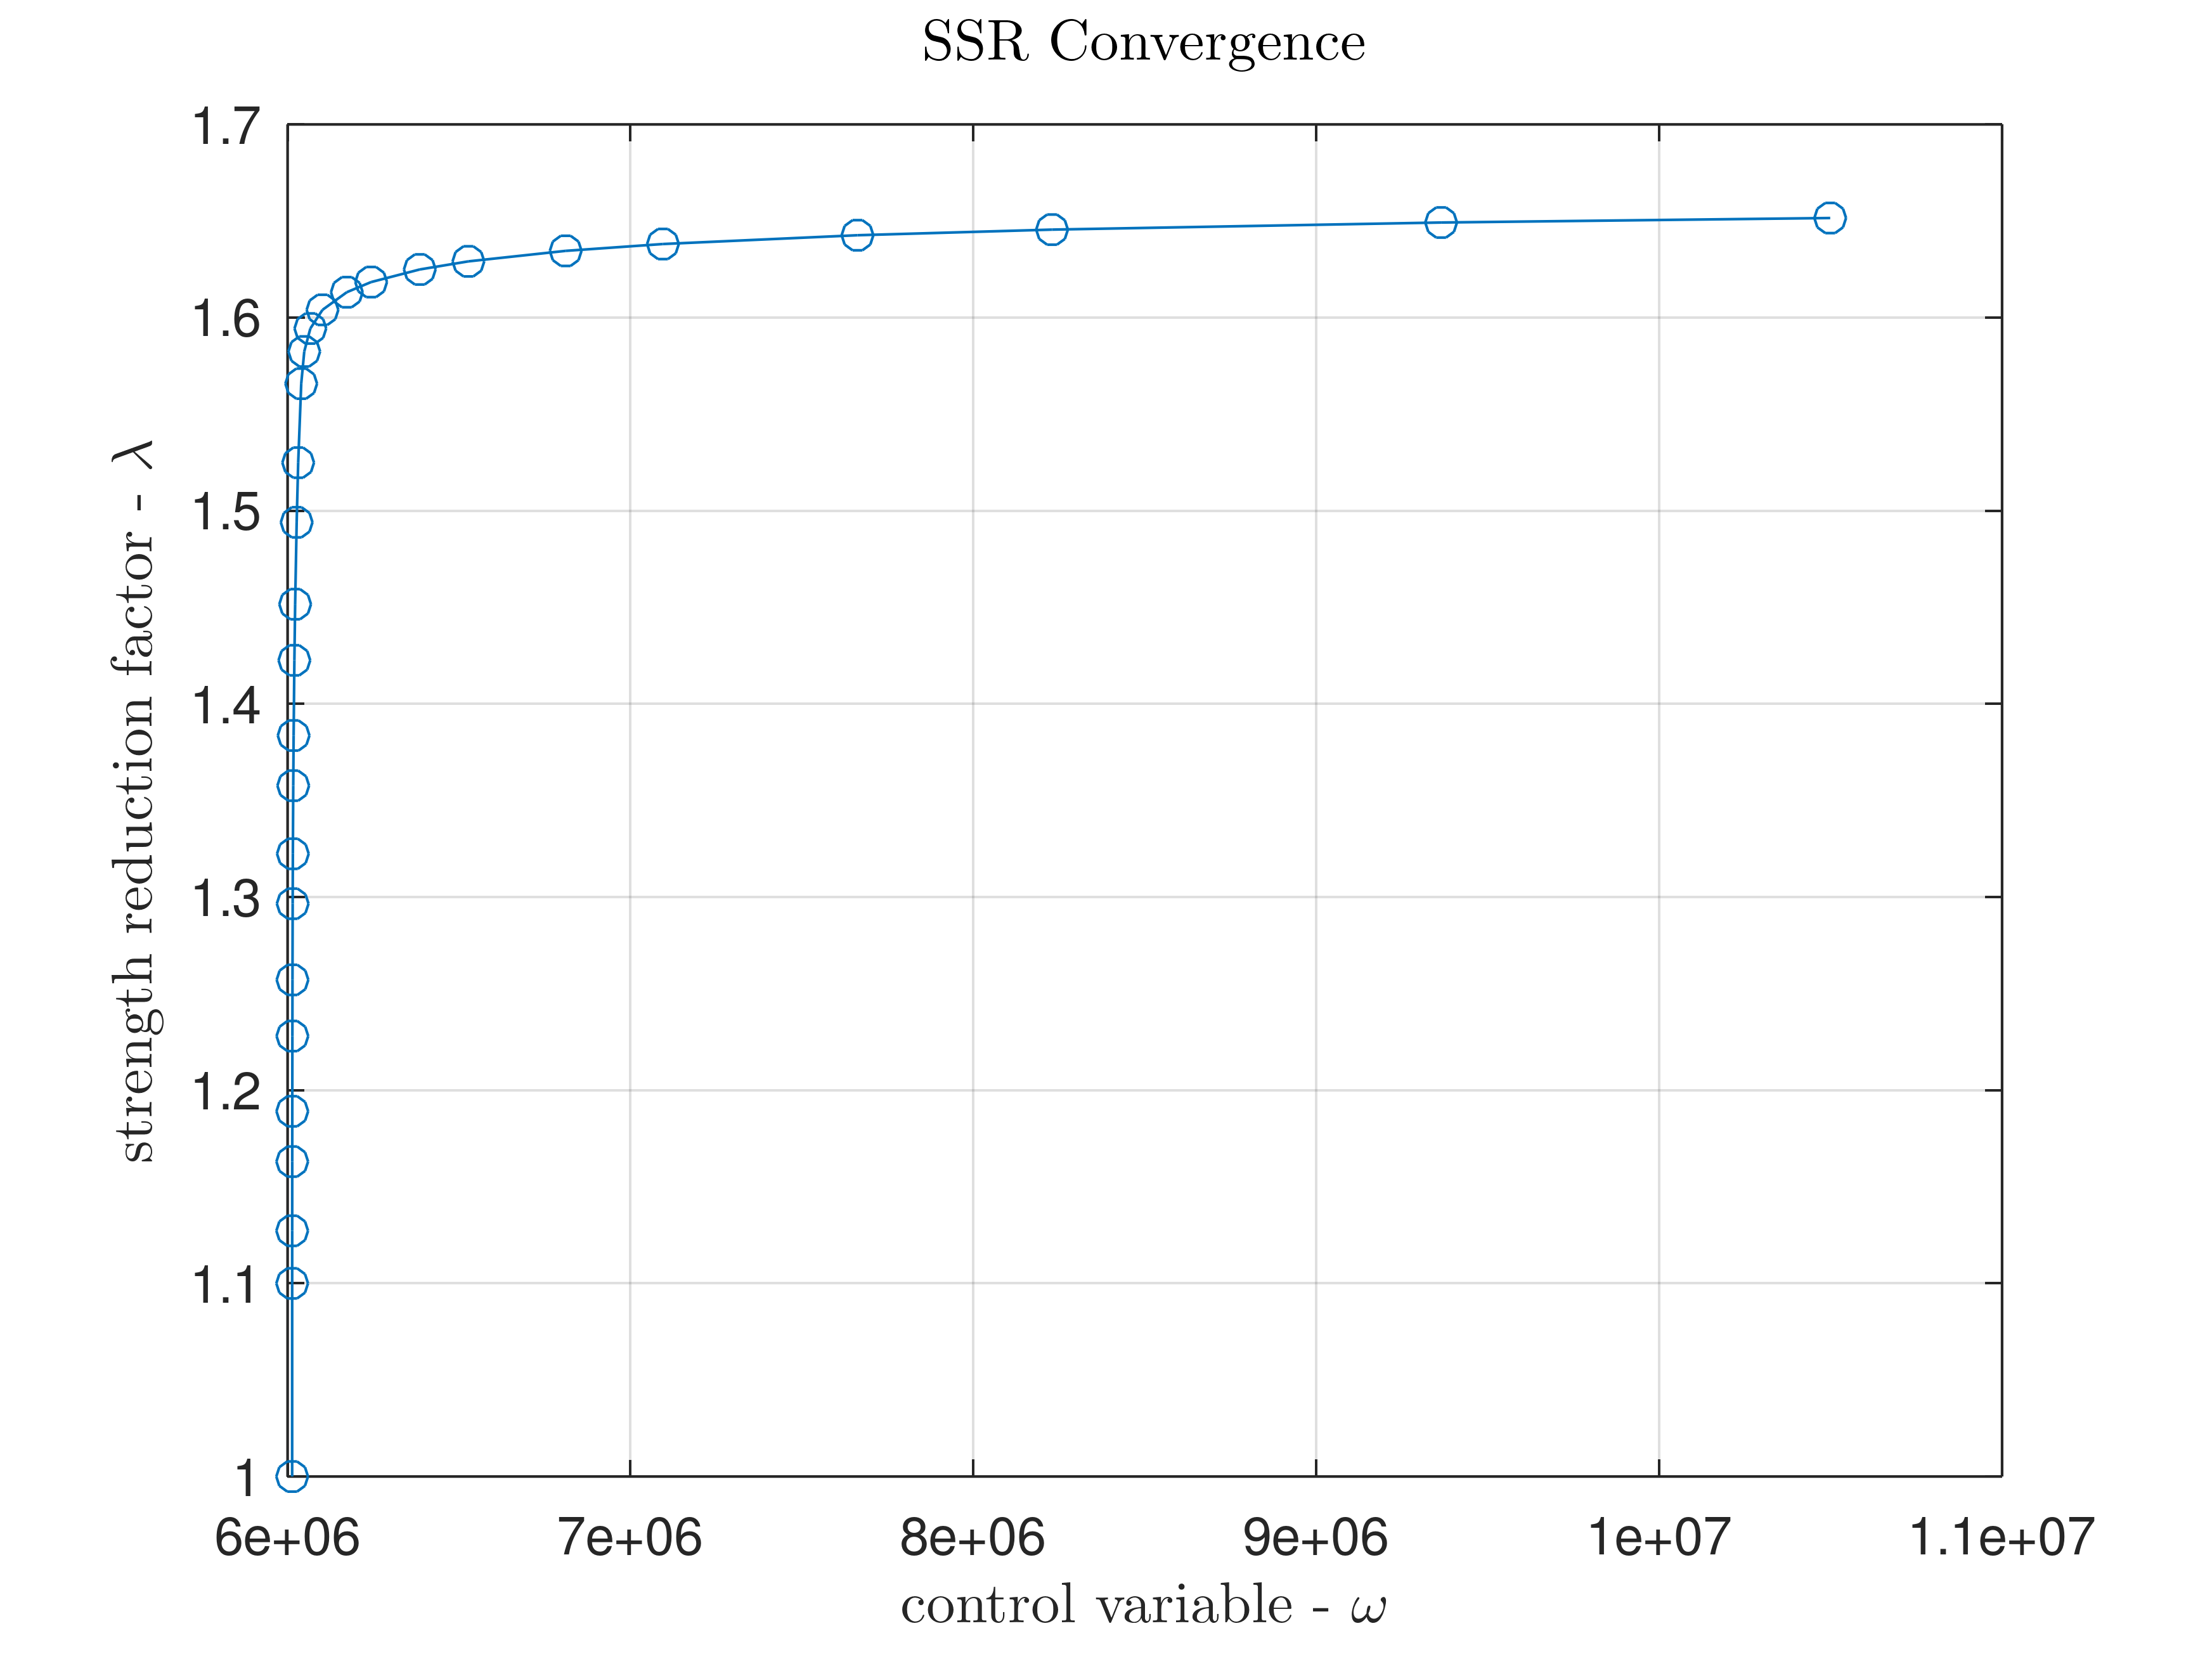

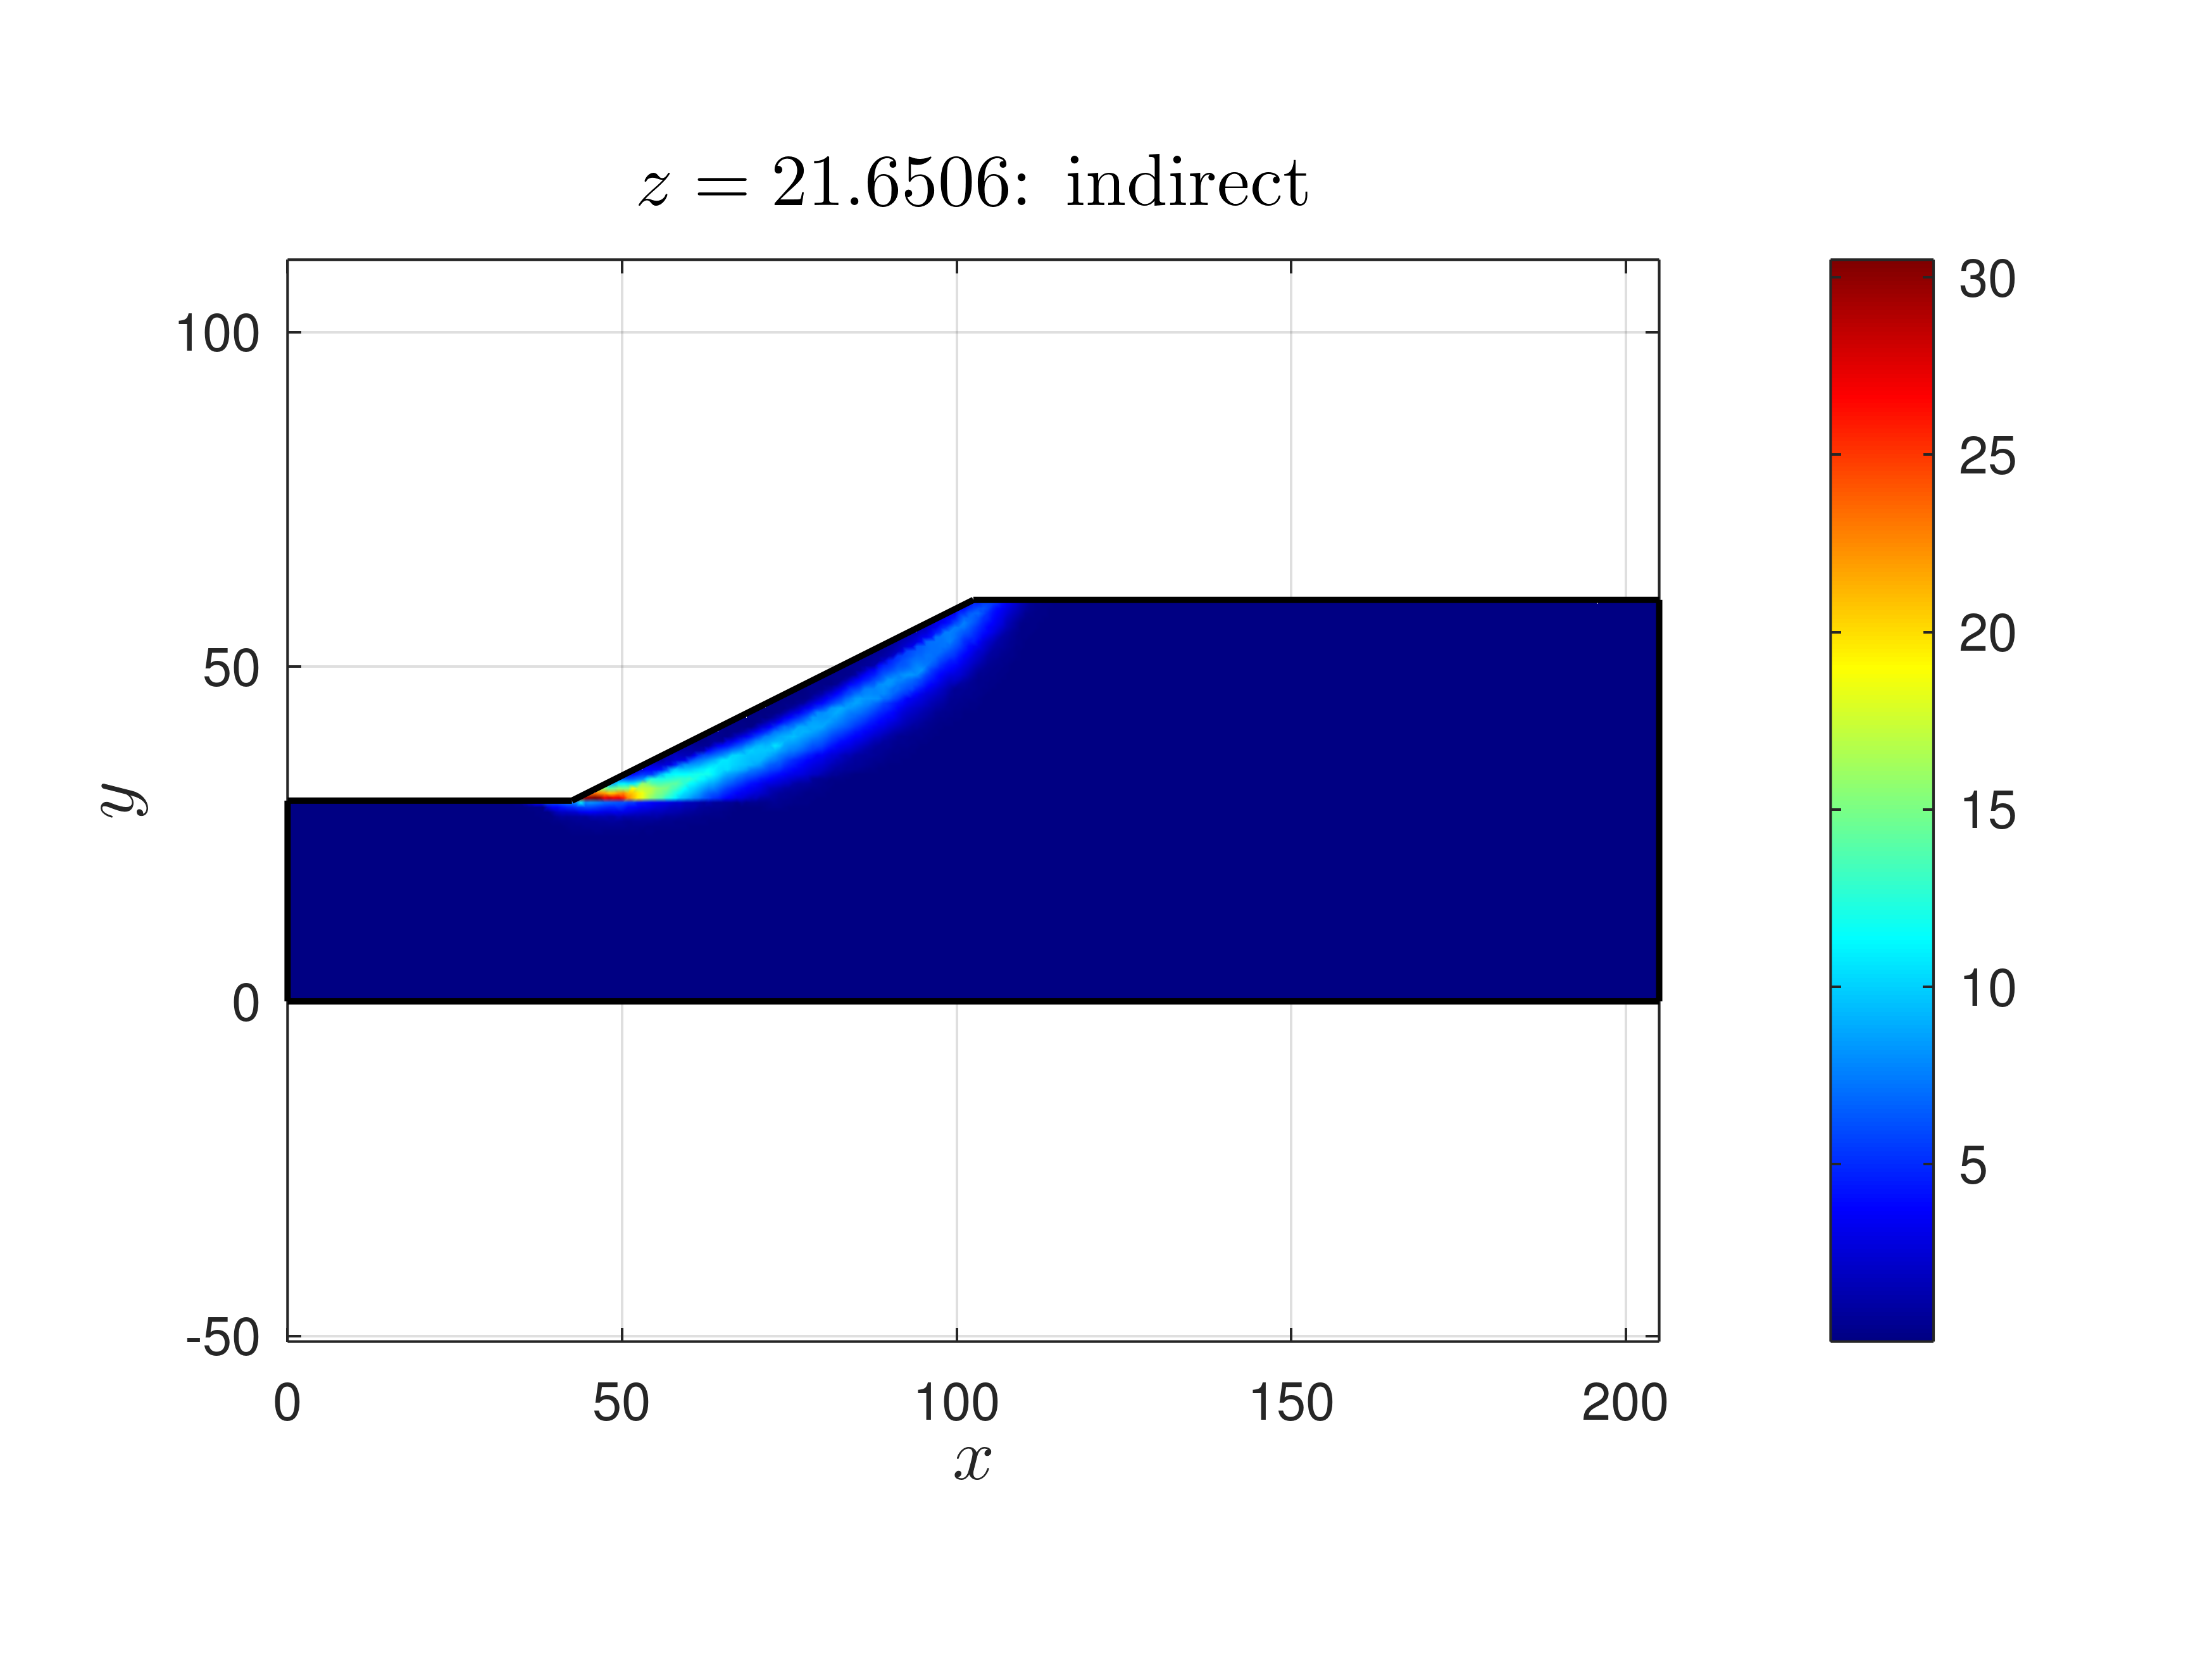

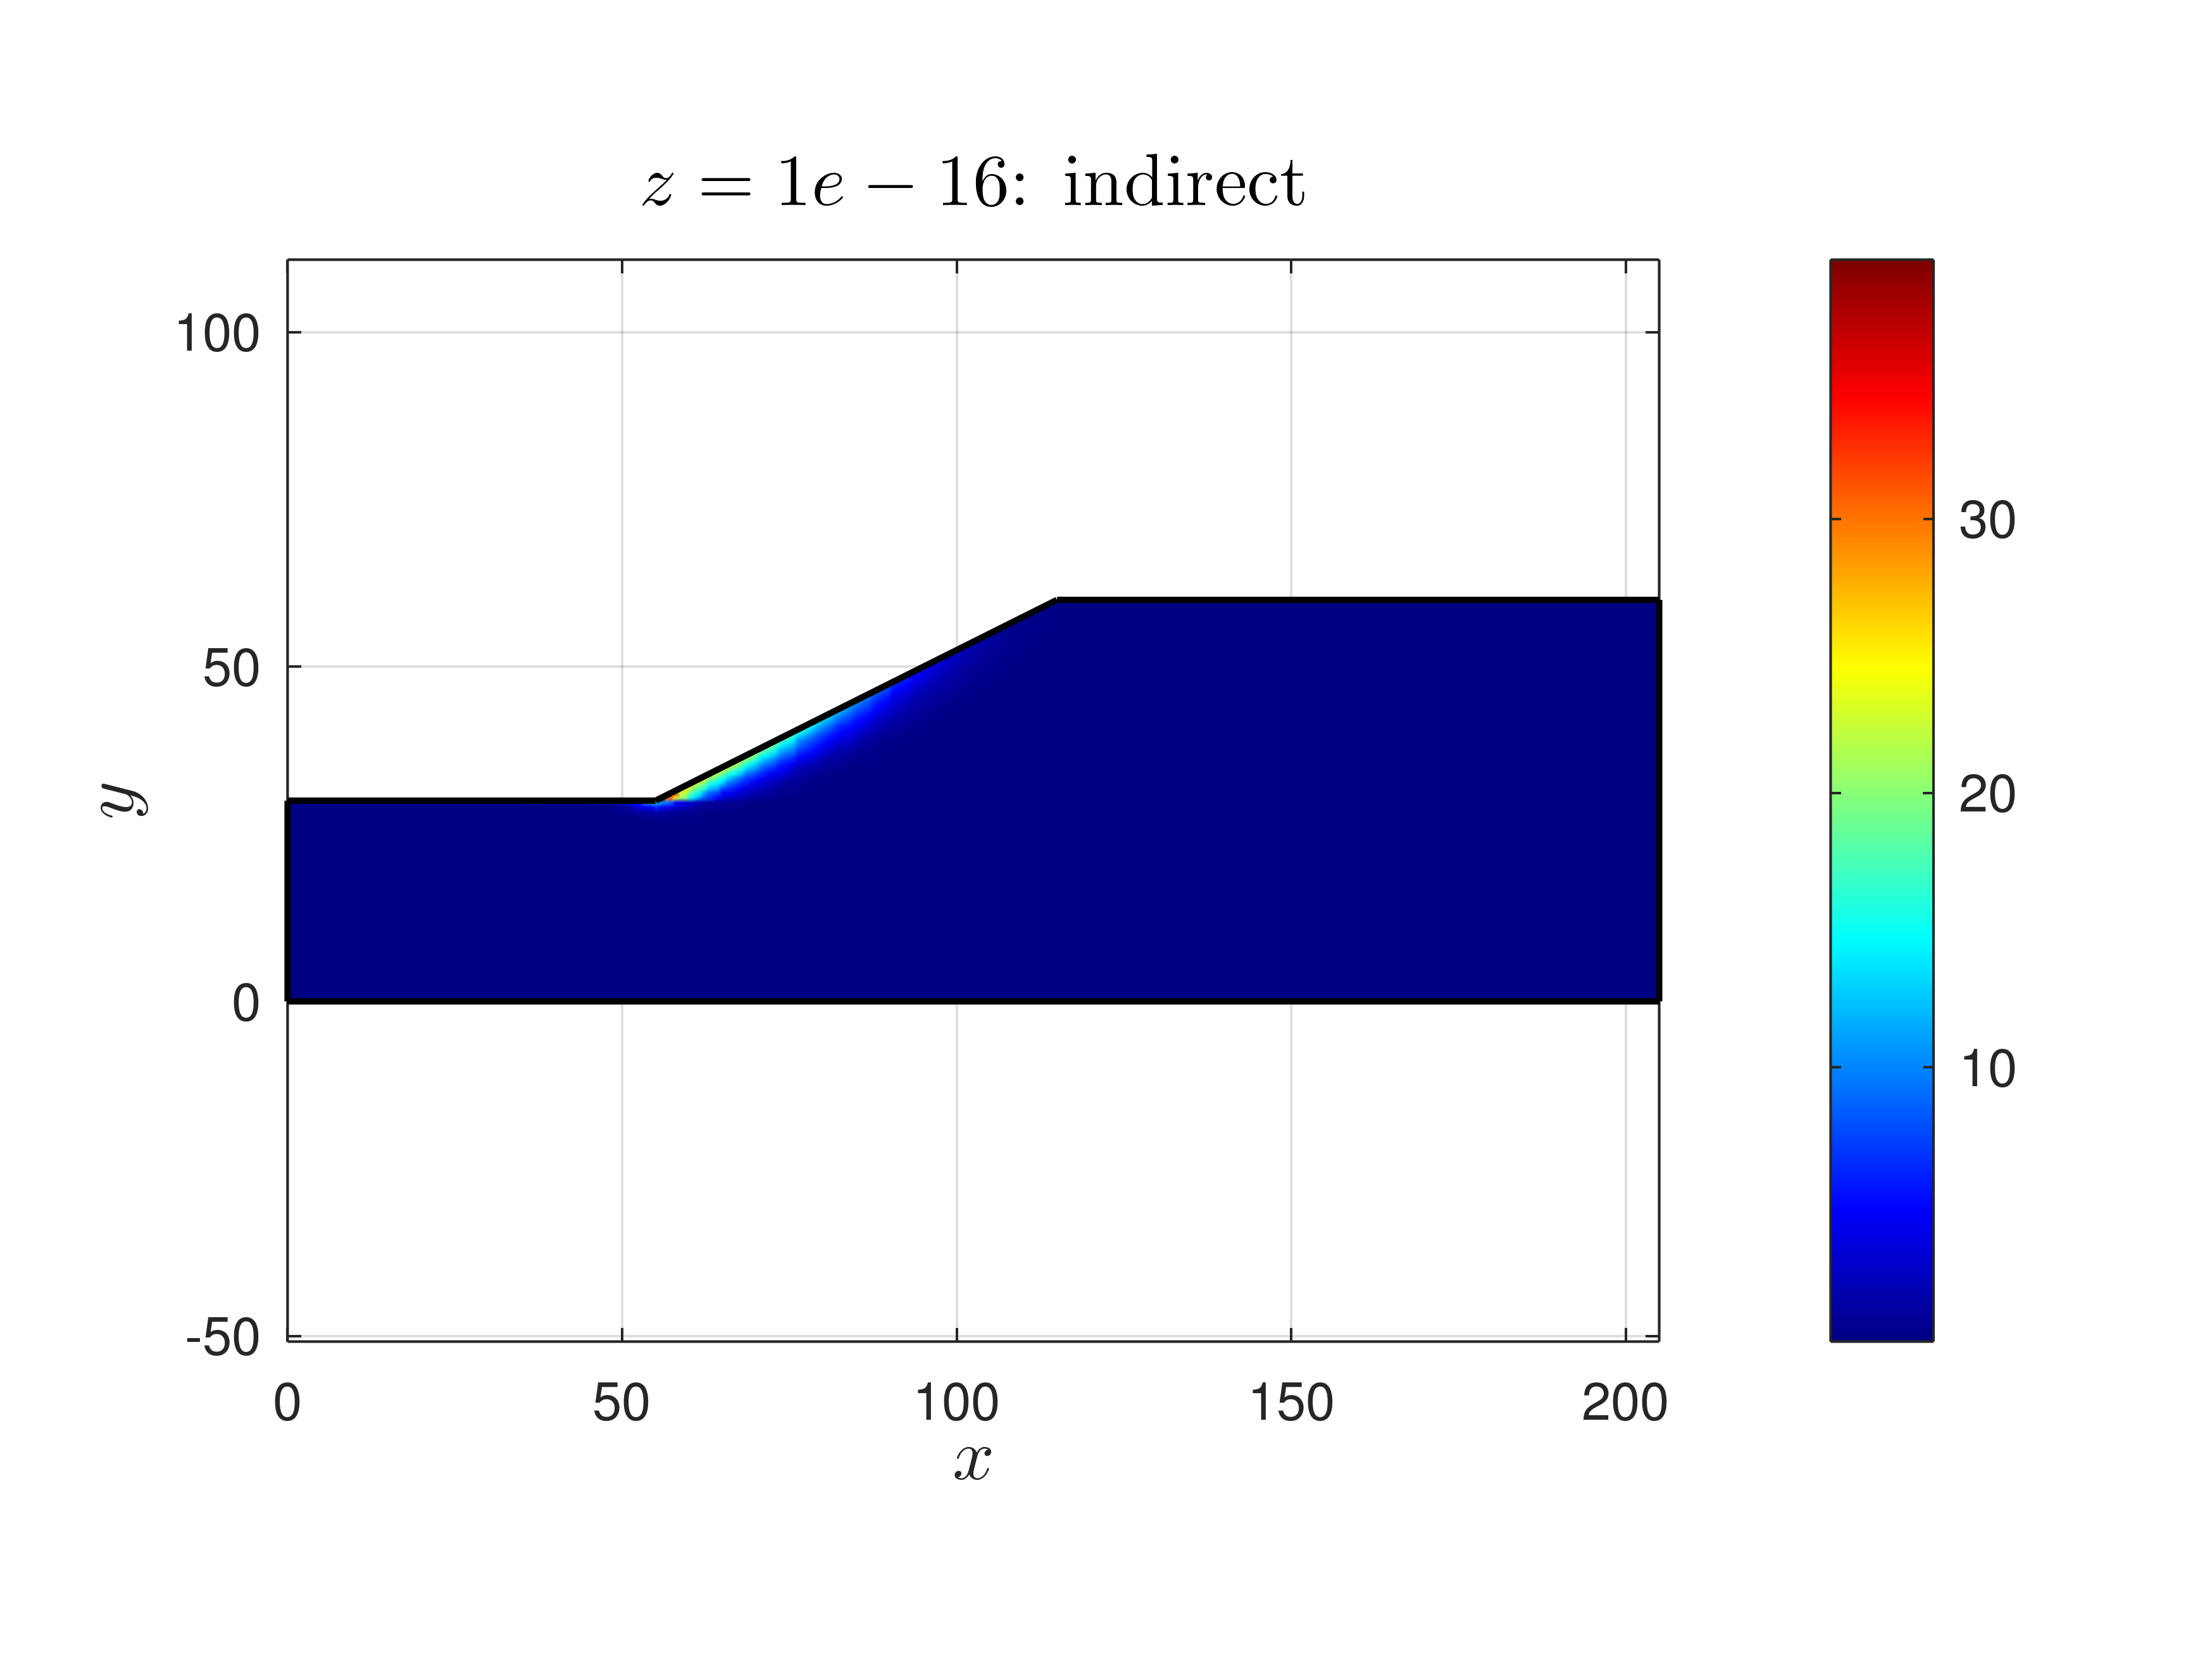

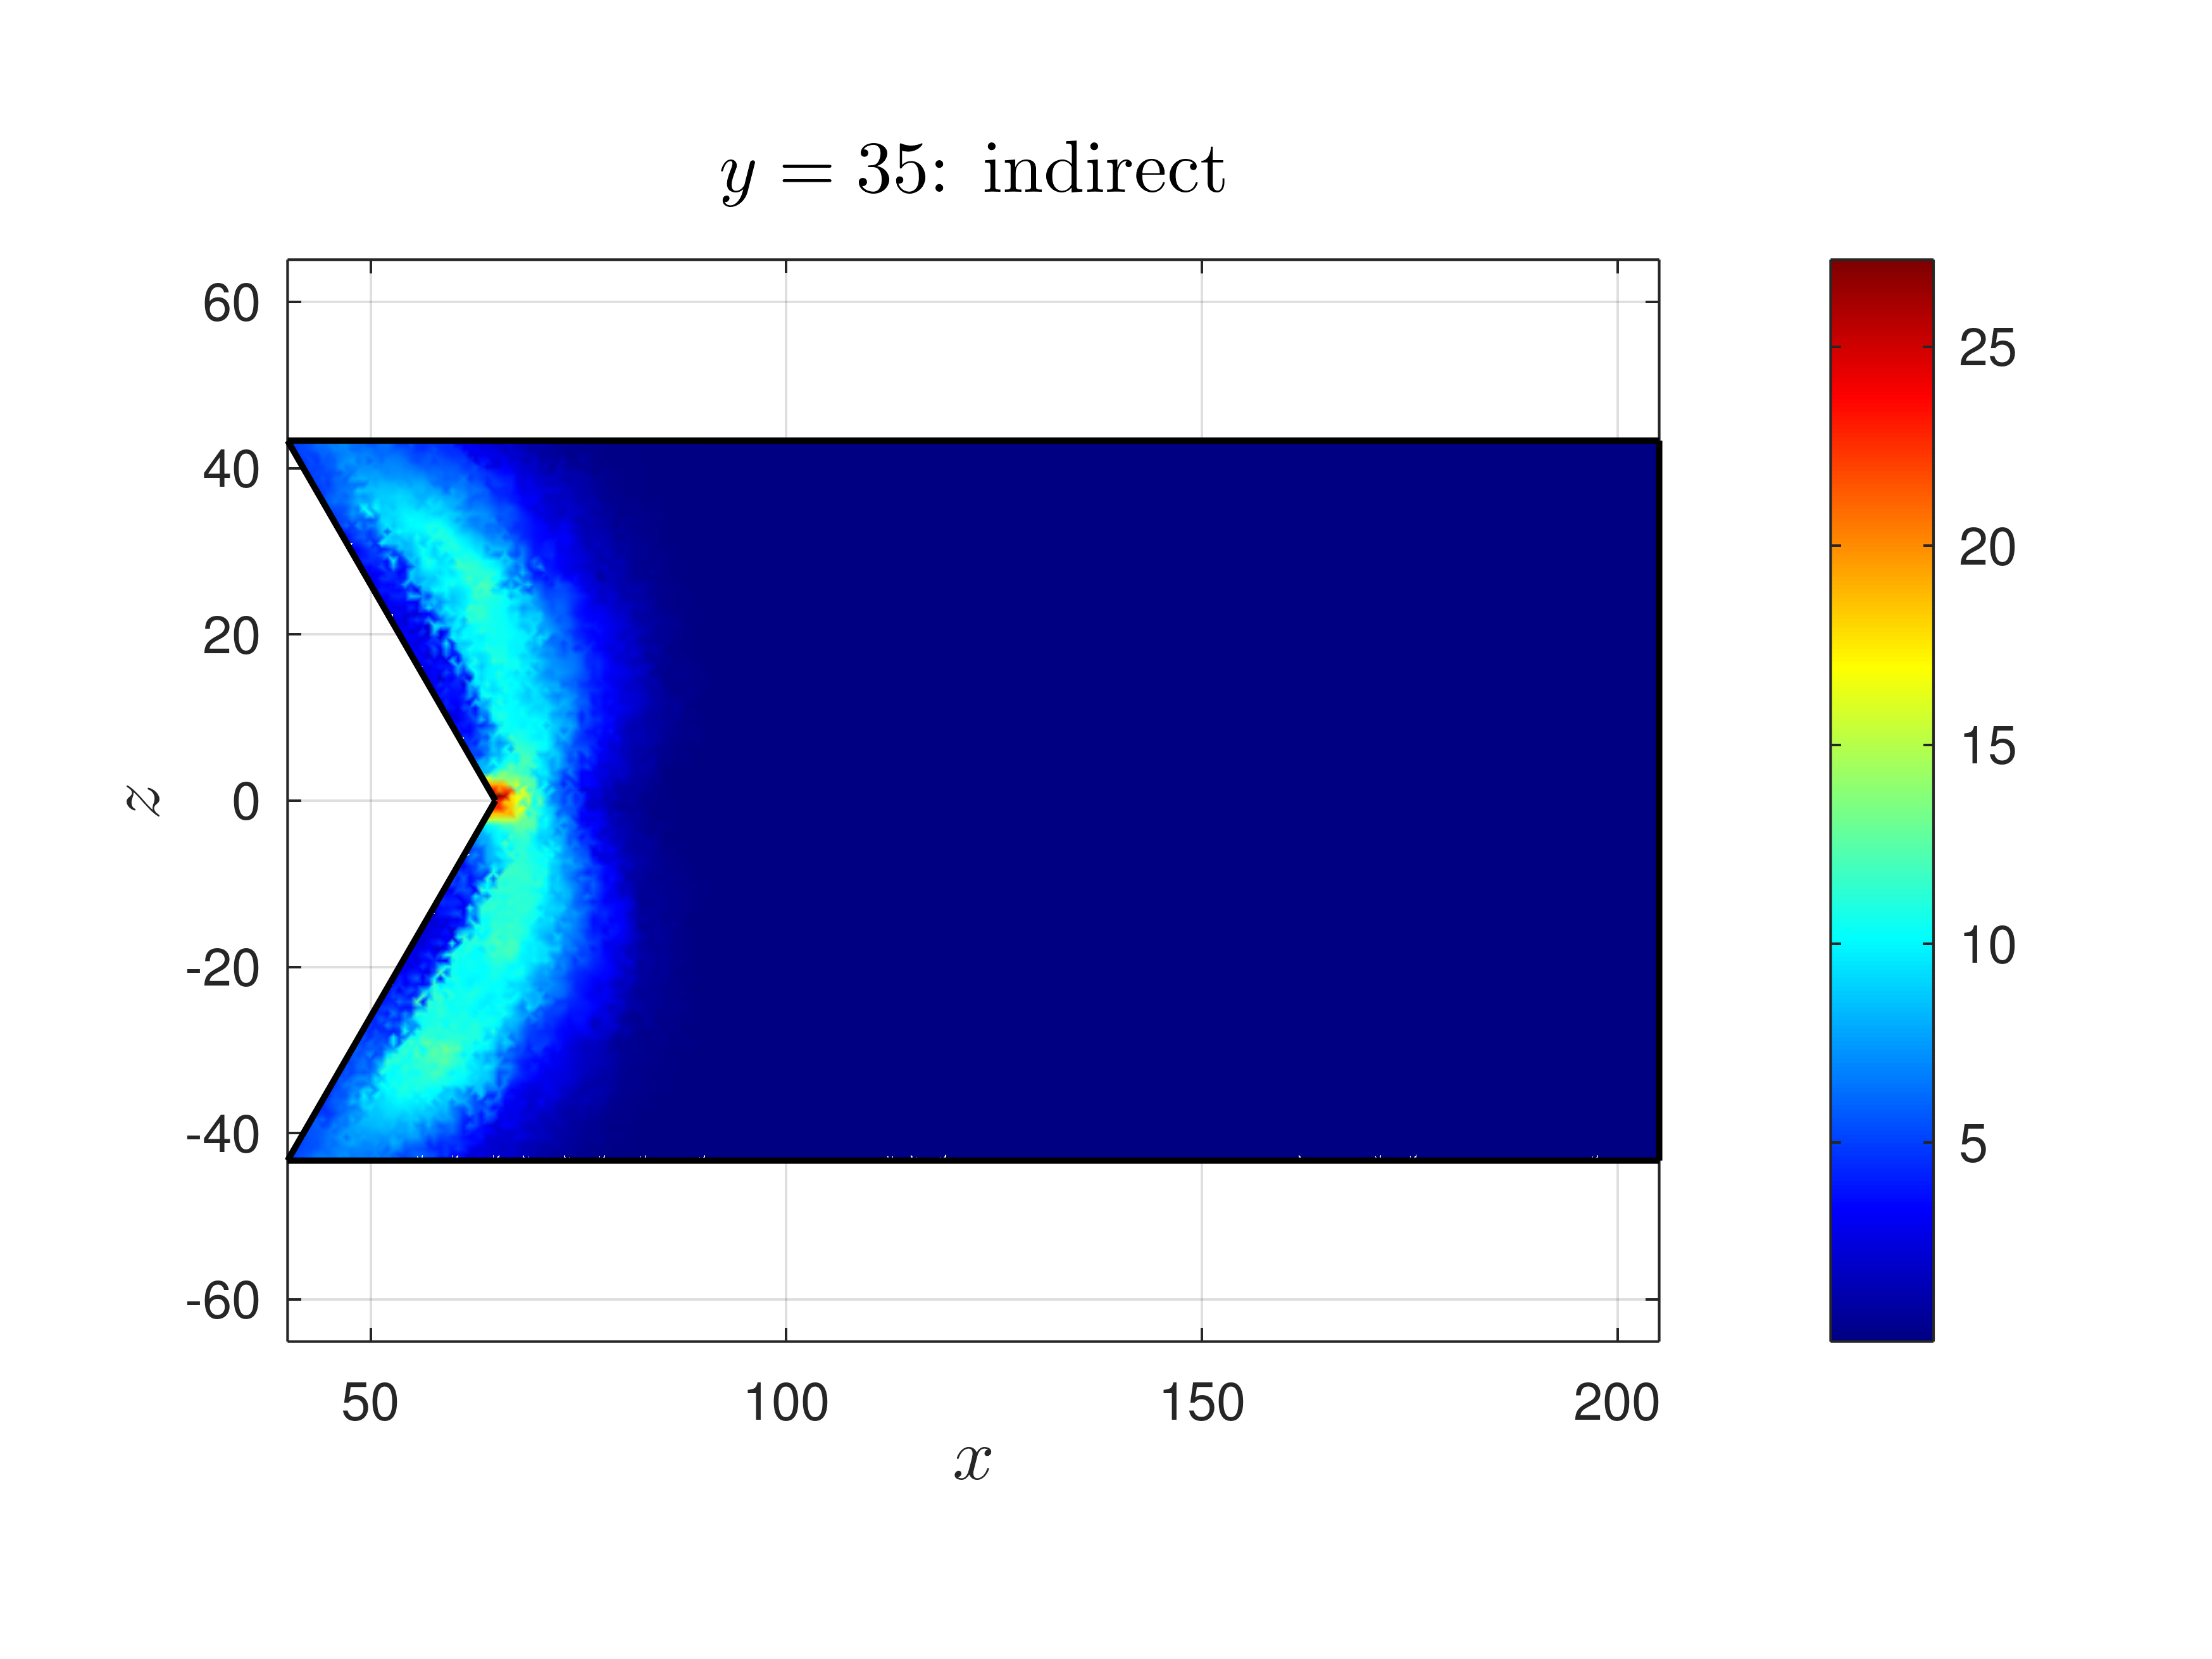

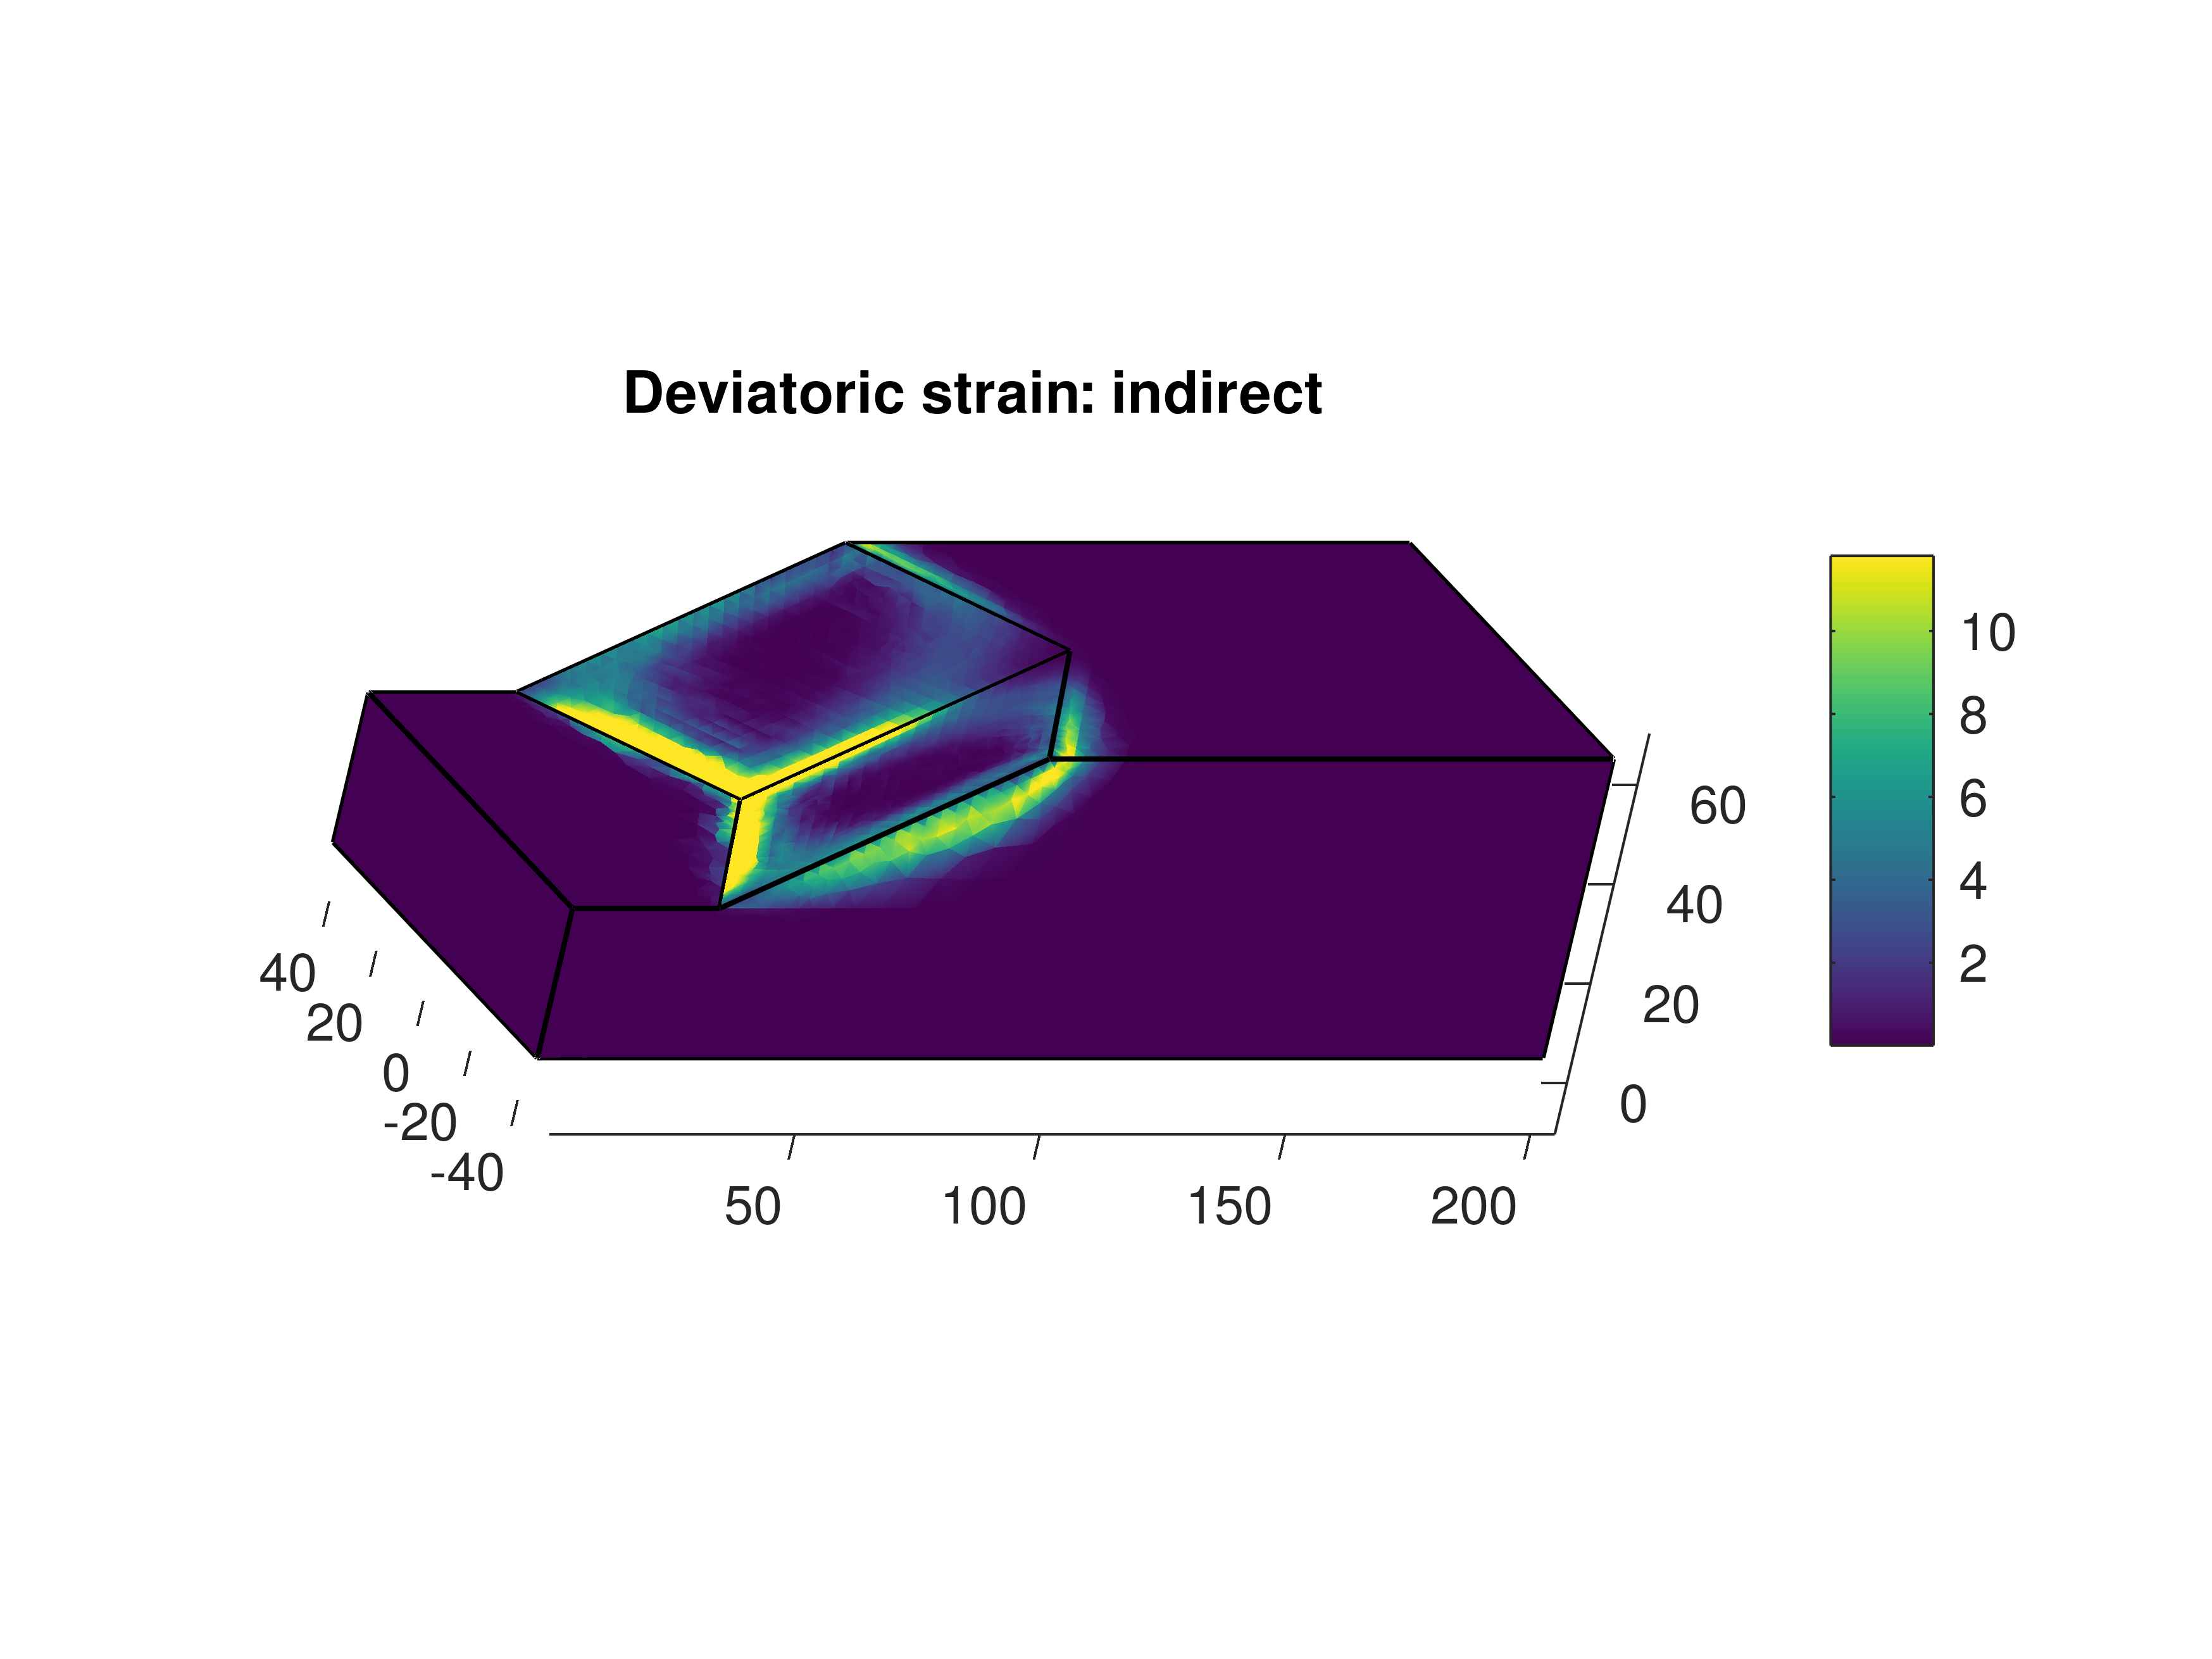

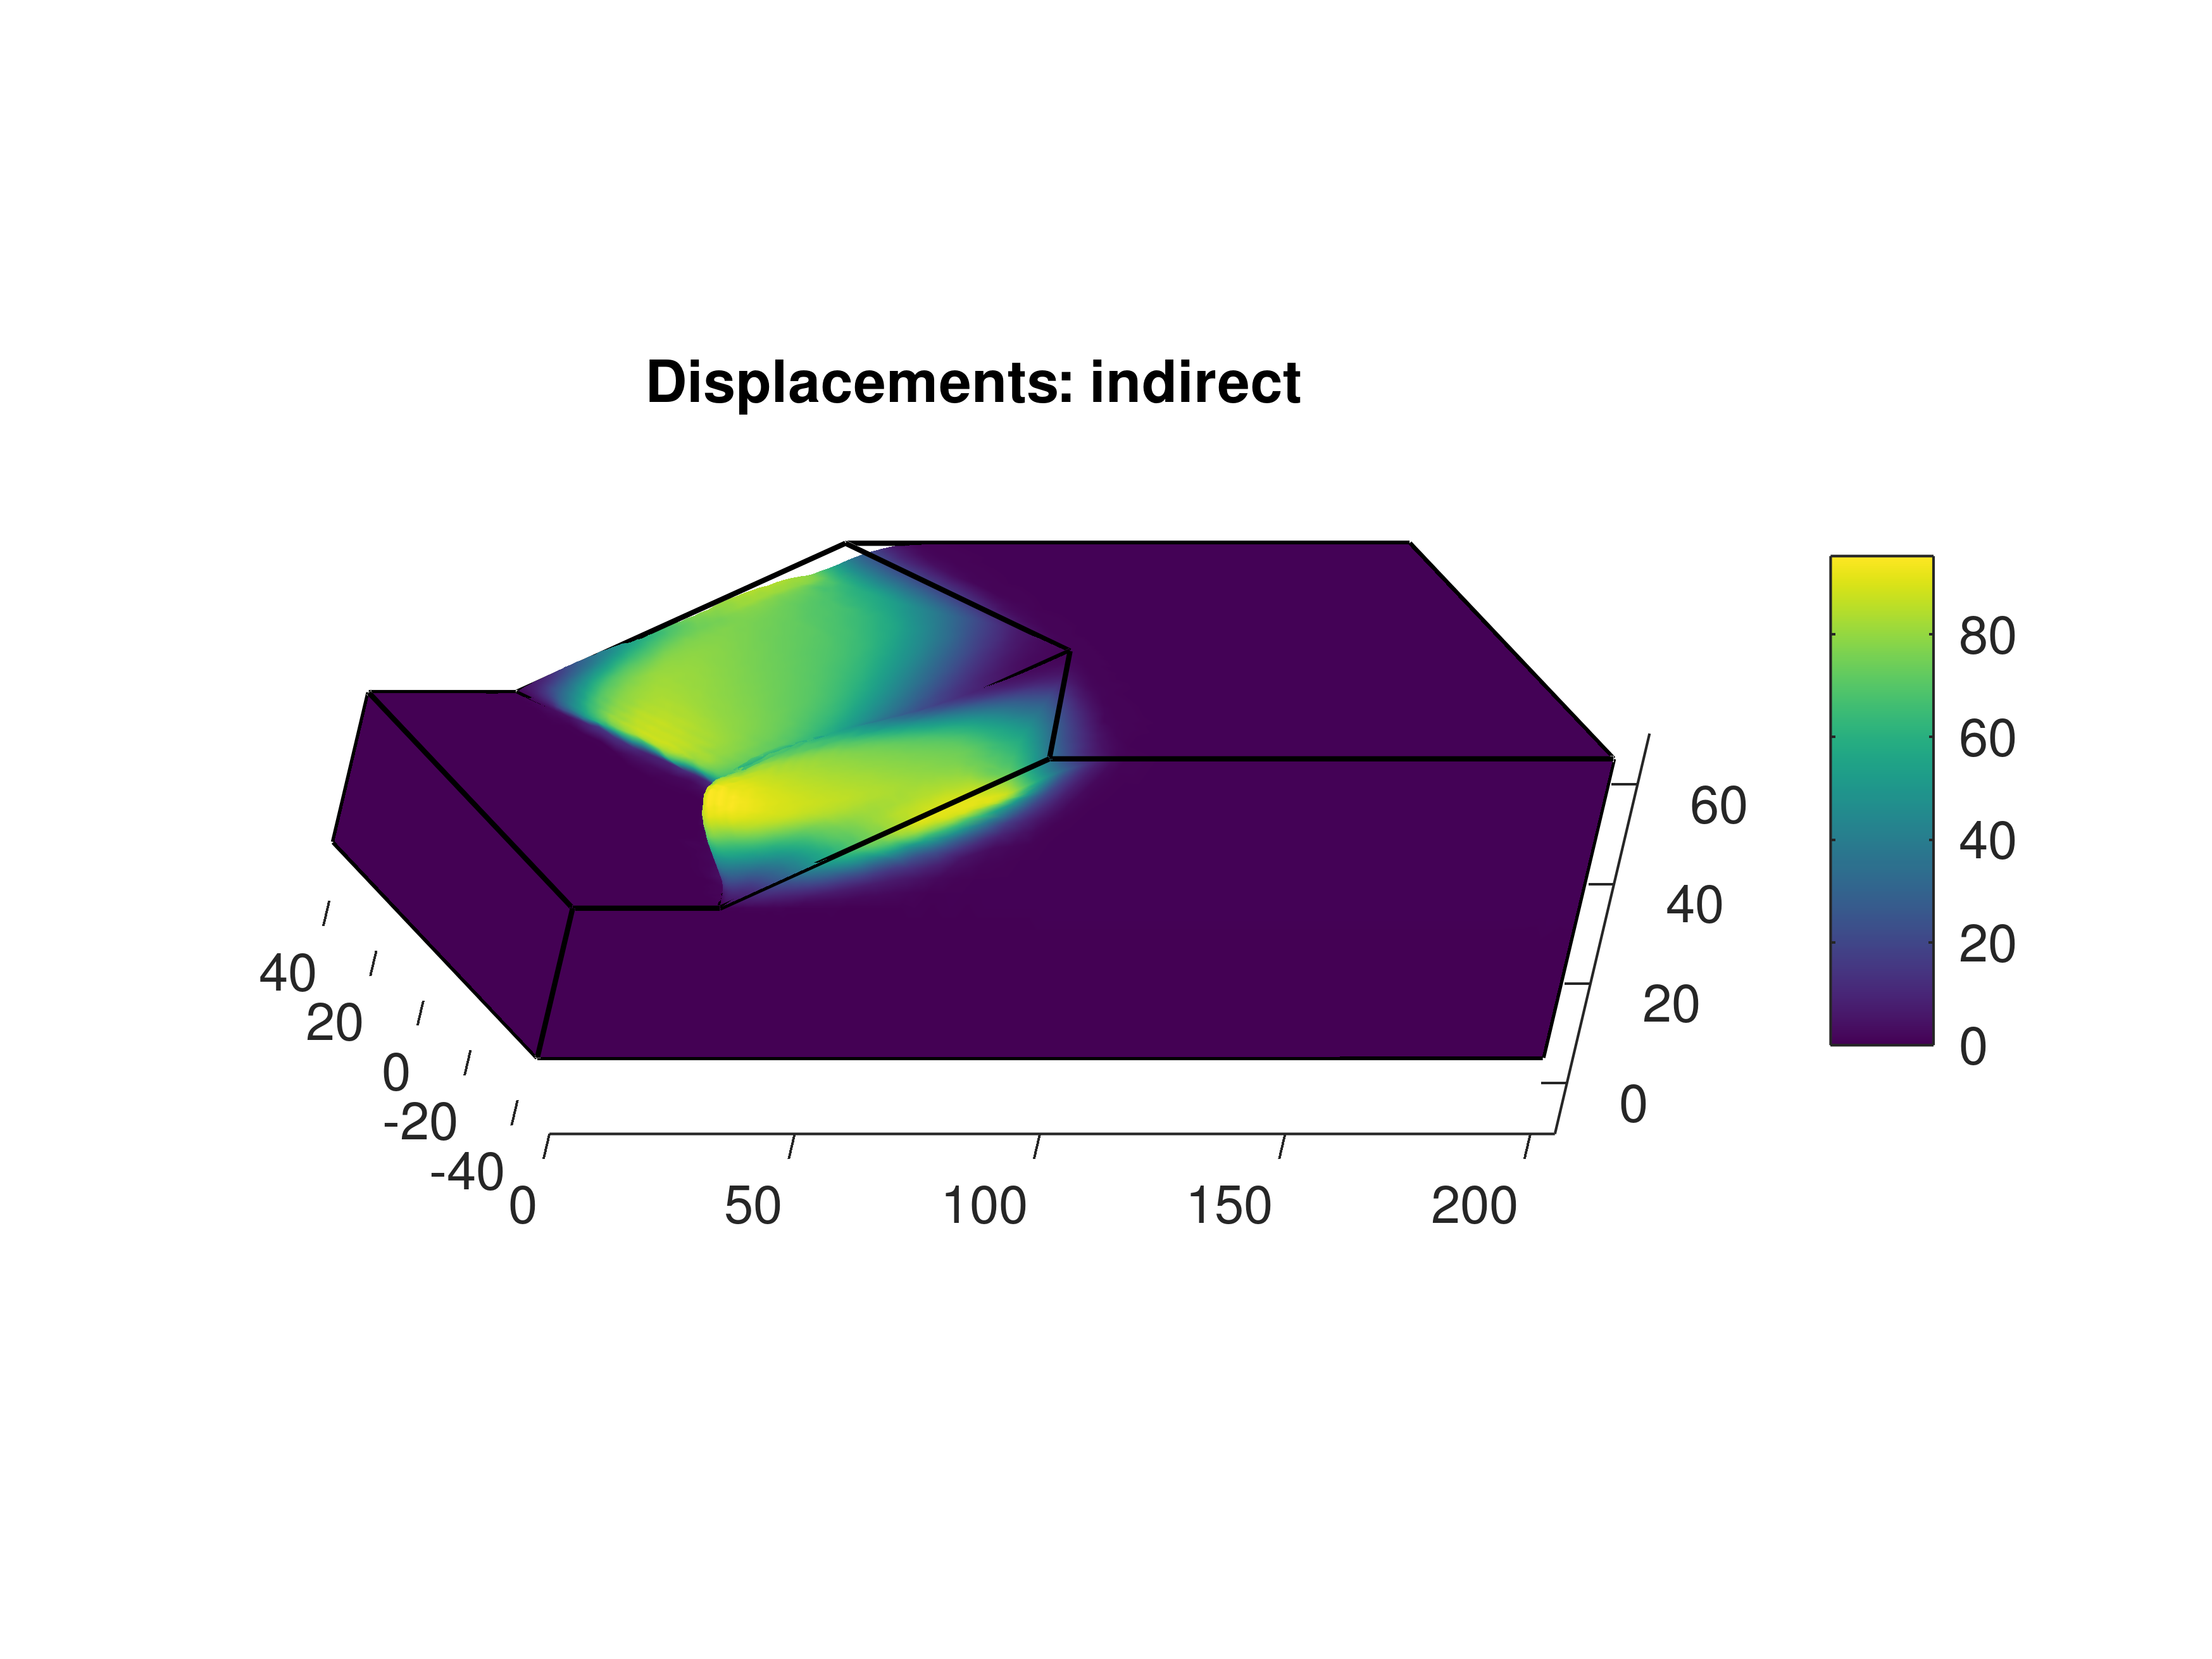

In [12]:
% Register computed solutions.
if direct_on
    plotter.add_solution('direct', U2, lambda_hist2, omega_hist2, Umax_hist2);
end
if indirect_on
    plotter.add_solution('indirect', U3, lambda_hist3, omega_hist3, Umax_hist3);
end

% Mechanical field plots.
plotter.plot_displacements();
drawnow; pause(0.2);

plotter.plot_deviatoric_strain(0.25);
drawnow; pause(0.2);

plane_vals = {[], [35], [1e-16, 21.6506]};
plotter.plot_deviatoric_slices(plane_vals, 1);
drawnow; pause(0.2);

plotter.plot_convergence();

fprintf('Notebook workflow completed.\n');